In [1]:
import numpy as np
import random
import functools
import yaml
import os
from deap import gp
from alpine.gp.gpsymbreg import GPSymbolicRegressor
import warnings
import ray
from sympy import symbols, lambdify, sin, sqrt, pprint, latex, cos, tanh
from IPython.display import display, Math
from ControllerComp import V_x, f, x, G, Q, R, safe_divideSR, compute_v_and_v_dot2

from Fitness import fitness
from PredictScoreFuncs import predict, score
import Functions
from SymFunctions import read_expression, DeapSimplifier
from V_Vdot_Calculations import compute_v_and_v_dot

import matplotlib.pyplot as plt

In [2]:
# Define the numerical grid (Domain)
x1_vals = np.linspace(-4, 4, 100)
x2_vals = np.linspace(-4, 4, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

In [ ]:

def main():
    yamlfile = "Lyapunov.yaml"
    filename = yamlfile
    with open(filename) as config_file:
        config_file_data = yaml.safe_load(config_file)

    pset = gp.PrimitiveSetTyped(
        "MAIN",
        [
            float, float
        ],
        float,
    )
    
    pset.renameArguments(ARG0="x1", ARG1="x2")
    
    #pset.addPrimitive(one_minus_cos, (float,), float)

    def random_constant():
        return random.uniform(-10, 10)

    pset.addEphemeralConstant("rand", functools.partial(random_constant), float)

    #pset.addEphemeralConstant("rand", lambda: random.uniform(-10, 10), float)
    #pset.addTerminal(1, float) 
    
    penalty = config_file_data["gp"]["penalty"]
    common_data = {"penalty": penalty}

    gpsr = GPSymbolicRegressor(
        pset=pset,
        fitness=fitness.remote,
        error_metric=score.remote,
        predict_func=predict.remote,
        common_data=common_data,
        config_file_data=config_file_data,
        print_log=True,
        batch_size=100,
    )

    train_data = Functions.Dataset("true_data", [x1_vals, x2_vals], None)
    gpsr.fit(train_data)

    # Access and save the best individual
    best_expression = gpsr.best  # Save the best expression
    best_fitness = gpsr.train_fit_history[-1]  # Save the best fitness score

    # Write best expression to a file
    with open("best_expression.txt", "w") as file:
        file.write(f"Best Expression:\n{best_expression}\n")
        file.write(f"Best Fitness:\n{best_fitness}\n")

    print("Best Expression and Fitness saved to 'best_expression.txt'.")

    ray.shutdown()


if __name__ == "__main__":
    main()


In [3]:
expression = read_expression("best_expression.txt")
#'x2**2 + (2*(x1-1.7) + x2)*(5.0822407008652038*(x1-1.7) - 0.52132989446725283*x2)'
#read_expression("best_expression.txt") #+ '+ 73'
#'0.01875 * x2**2 + 0.73575 * (1 - cos(x1))'
#'x1**2 + x2**2'

simplified_expr = DeapSimplifier(expression)
display(Math(latex(simplified_expr)))

Original Expression: mul(sub(sub(-4.698883589468692, -5.758667687109349), mul(add(x1, x2), sub(sub(-7.9511944483222585, sub(5.602195452007546, -4.698883589468692)), -4.698883589468692))), add(x1, x2))
Simplified Expression: (x1 + x2)*(13.553389900329805*x1 + 13.553389900329805*x2 + 1.059784097640657)


<IPython.core.display.Math object>

In [4]:
# Define symbolic variables
x1, x2 = symbols('x1 x2')
V_func = lambdify((x1, x2), simplified_expr, modules='numpy')
V_vals = V_func(X1, X2)

In [5]:
print(x1_vals.shape)

(100,)


In [6]:
_, V_grad_mag, V_dot_vals, lambda_vals, u_vals, u_vals2, u_mag, a_vals, b_nvals = compute_v_and_v_dot(V_vals, x1_vals, x2_vals)

In [7]:
V_violations = np.count_nonzero(V_vals < 0)
print(V_violations)

Vdot_violations = np.count_nonzero(V_dot_vals > -1)
print(Vdot_violations)

a_violations = np.count_nonzero((a_vals > 0) & (b_nvals < 0.001))
print(a_violations)


0
0
0


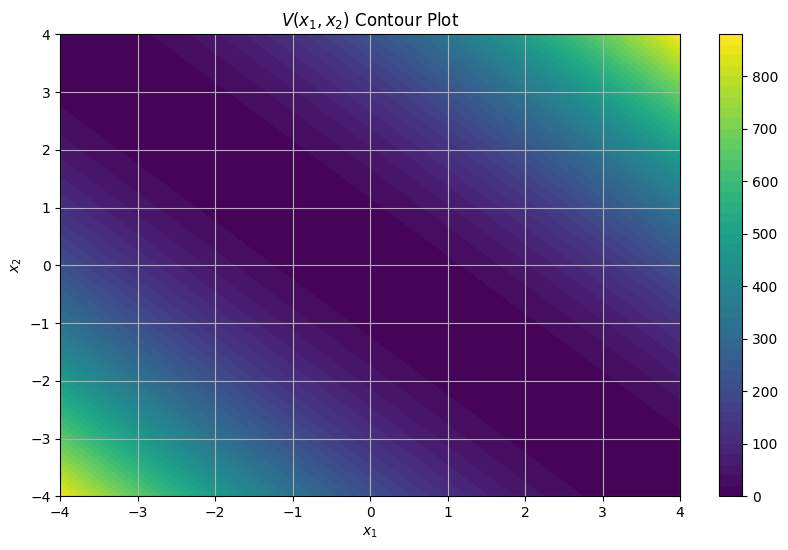

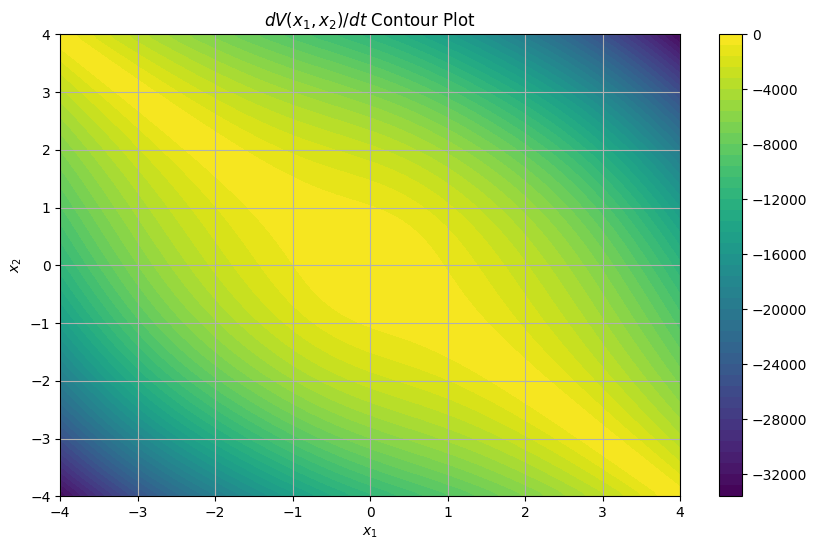

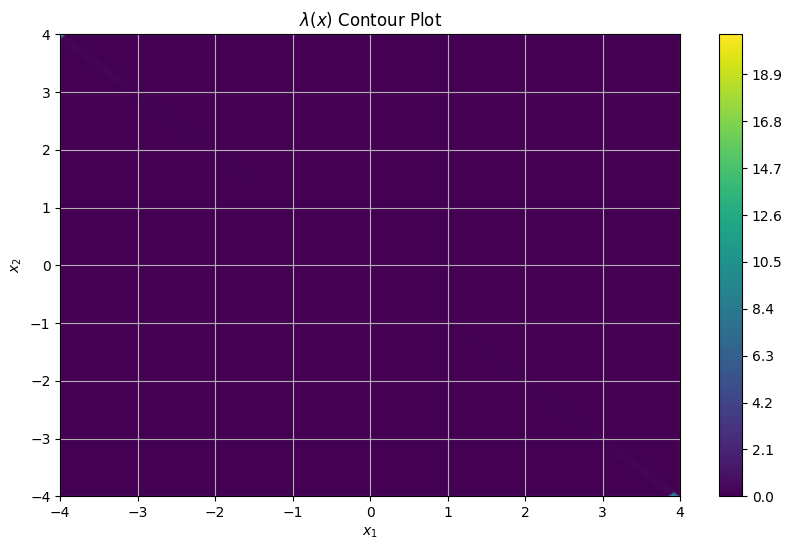

mean value of lambda:
0.008824285558964086


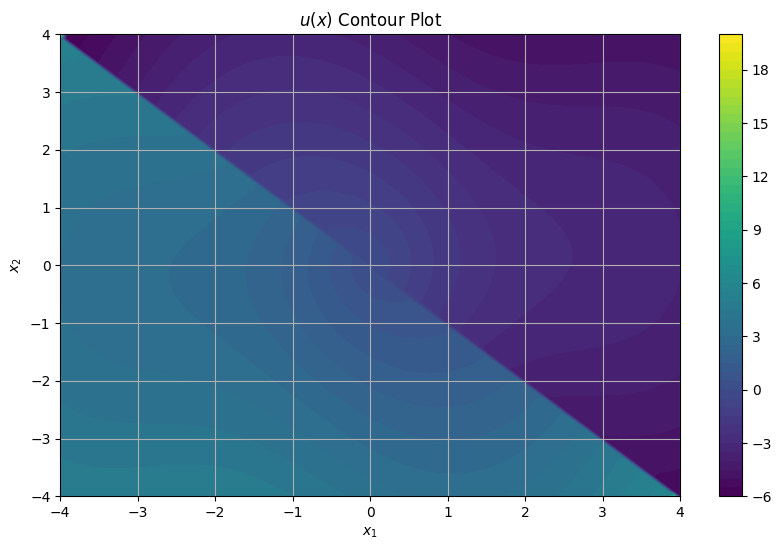

-0.026104753102828726


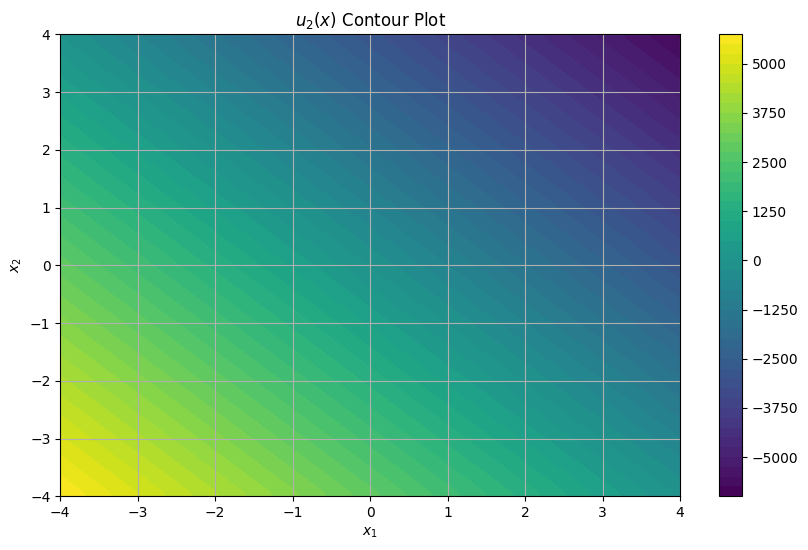

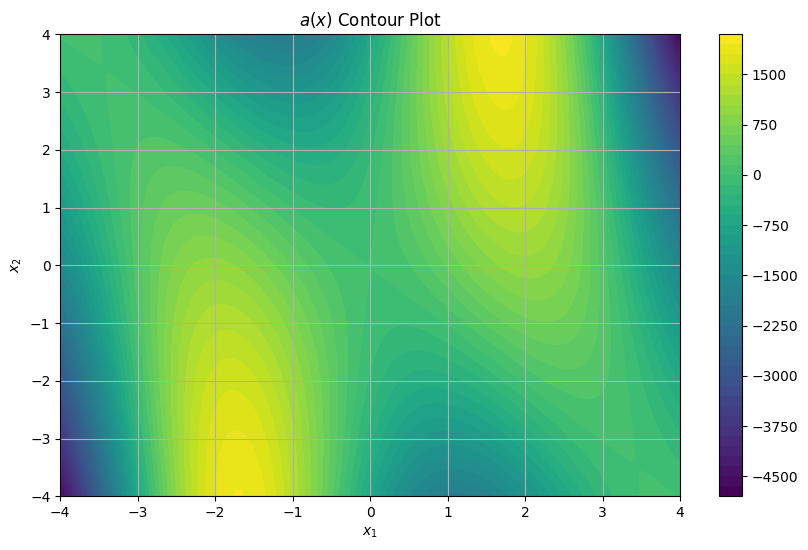

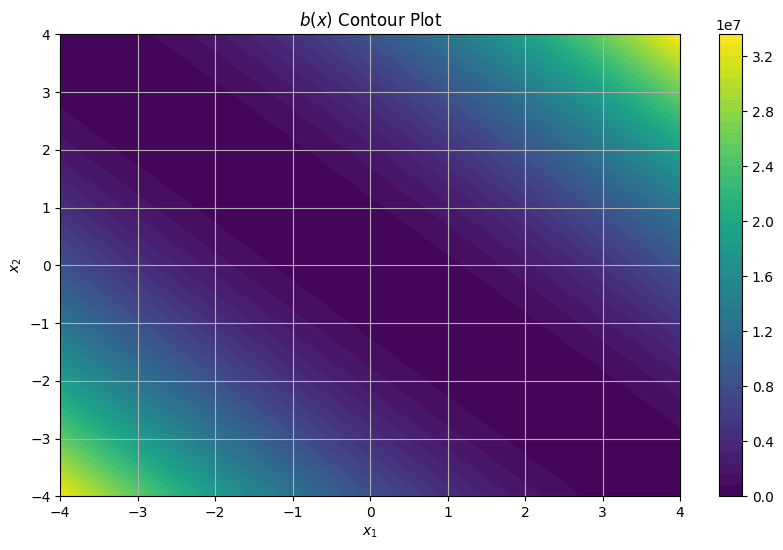

In [16]:
import matplotlib.pyplot as plt

X1 = x1_vals
X2 = x2_vals

# Plot V(x1, x2)
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, V_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$V(x_1, x_2)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of V_x1
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, V_dot_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$d V(x_1, x_2) / dt$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of lambda_x
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, lambda_vals, levels=500, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$\lambda(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

print('mean value of lambda:')
print(np.mean(lambda_vals))

# Plot the contour of u
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, u_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$u(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()
#levels=np.linspace(-10, 10, 50)
print(np.mean(u_vals))

# Plot the contour of u2
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, u_vals2, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$u_2(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of a
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, a_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$a(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of b
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, b_nvals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$b(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

In [9]:
V = simplified_expr
x1, x2 = symbols('x1 x2')
V_grad = V_x(V, x1, x2)
x_vector = x(x1, x2)
f_vector = f(x1, x2)
G_matrix = G(x1, x2)
Q_matrix = Q(x1, x2)
R_matrix = R(x1, x2)

V_func, V_dot_func, lambda_func, u_func, u_func2, u_mag, b_norm_squared = compute_v_and_v_dot2(V)

print(u_func)
u_func

1.9090689828141357e-6*(-723.75102067761155*x1 - 723.75102067761155*x2 - 28.29623540700554)*(x2*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657) + (-2.66666666666667*x2 + 19.62*sin(x1))*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657) + 723.75102067761155*sqrt((x1**2 + x2**2)*(x1 + x2 + 0.039096643180569477)**2 + 1.9090689828141357e-6*(x2*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657) + (-2.66666666666667*x2 + 19.62*sin(x1))*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657))**2))/(x1 + x2 + 0.039096643180569477)**2


1.9090689828141357e-6*(-723.75102067761155*x1 - 723.75102067761155*x2 - 28.29623540700554)*(x2*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657) + (-2.66666666666667*x2 + 19.62*sin(x1))*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657) + 723.75102067761155*sqrt((x1**2 + x2**2)*(x1 + x2 + 0.039096643180569477)**2 + 1.9090689828141357e-6*(x2*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657) + (-2.66666666666667*x2 + 19.62*sin(x1))*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657))**2))/(x1 + x2 + 0.039096643180569477)**2

In [10]:
b_norm_squared

523815.5399318845*(x1 + x2 + 0.039096643180569477)**2

In [11]:
print(V_dot_func)

x2*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657) + (-2.66666666666667*x2 + 19.62*sin(x1))*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657) + 1.9090689828141357e-6*(-723.75102067761155*x1 - 723.75102067761155*x2 - 28.29623540700554)*(723.75102067761155*x1 + 723.75102067761155*x2 + 28.29623540700554)*(x2*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657) + (-2.66666666666667*x2 + 19.62*sin(x1))*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657) + 723.75102067761155*sqrt((x1**2 + x2**2)*(x1 + x2 + 0.039096643180569477)**2 + 1.9090689828141357e-6*(x2*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657) + (-2.66666666666667*x2 + 19.62*sin(x1))*(27.106779800659609*x1 + 27.106779800659609*x2 + 1.059784097640657))**2))/(x1 + x2 + 0.039096643180569477)**2


In [12]:
from sympy import symbols, Function, Matrix, Eq, dsolve
from SystemDynamics import f, G, Q, R
from NumSol import NumSol
import matplotlib.pyplot as plt

In [13]:
x1, x2 = symbols('x1 x2')

from sympy import symbols, lambdify, diff, Matrix, sin, cos, exp, log, sqrt, tanh

#u_func = -0.025467670686794*x1 - 0.19026288312708*x2
#u_func = 20 * tanh(-23.28 * x1 + -5.27 * x2)
#u_func = (-73*x1 - 40*x2)*(sqrt((73*x1 + 40*x2)**2*(x1**2 + x2**2) + (x2*(126*x1 + 73*x2) + (73*x1 + 40*x2)*(0.666666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(126*x1 + 73*x2) + (73*x1 + 40*x2)*(0.666666666666667*x2 - 19.62*sin(x1)))/(73*x1 + 40*x2)**2)
#u_func = (-68*x1 - 144*x2)*(sqrt((68*x1 + 144*x2)**2*(x1**2 + x2**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))/(68*x1 + 144*x2)**2)

T = 4
x1_0, x2_0 = 1, 1
#3,0 #-3, -3#-2.5, 0#1, 1# 4, 0
#t_vals, x1_vals, x2_vals = NumSol(u_func, T, x1_0, x2_0)

In [14]:
u_func_LQR = (-52.8710733230119*x1 - 26.0669049858921*x2)/26.7
#-(14.1518 * x1 + 2.4269 * x2)
#-0.025467670686794*x1 - 0.19026288312708*x2
#-39.2654676706868*x1 - 6.64150428430349*x2
t_vals_L, x1_vals_L, x2_vals_L = NumSol(u_func_LQR, T, x1_0, x2_0, None)

u_func_NN = 20 * tanh(-23.28 * x1  -5.27 * x2) #* 26.6 
t_vals_N, x1_vals_N, x2_vals_N = NumSol(u_func_NN, T, x1_0, x2_0, None)

#u_func_CLF = (-68*x1 - 144*x2)*(sqrt((68*x1 + 144*x2)**2*(x1**2 + x2**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))/(68*x1 + 144*x2)**2)
u_func_CLF = u_func * 1
t_vals_C, x1_vals_C, x2_vals_C = NumSol(u_func_CLF, T, x1_0, x2_0, b_norm_squared)


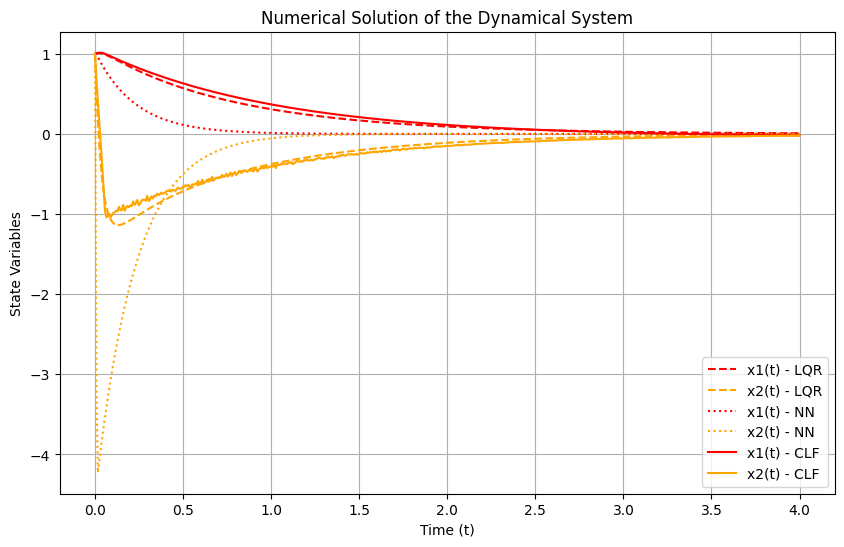

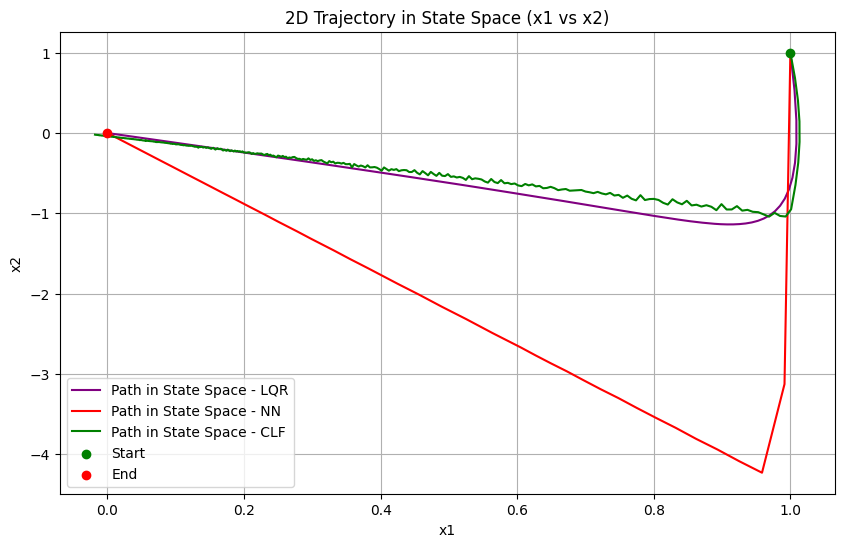

In [16]:
# Plot the solution
plt.figure(figsize=(10, 6))

plt.plot(t_vals_L, x1_vals_L, label="x1(t) - LQR", color="red", linestyle='--')
plt.plot(t_vals_L, x2_vals_L, label="x2(t) - LQR", color="orange", linestyle='--')

plt.plot(t_vals_N, x1_vals_N, label="x1(t) - NN", color="red", linestyle=':')
plt.plot(t_vals_N, x2_vals_N, label="x2(t) - NN", color="orange", linestyle=':')

plt.plot(t_vals_C, x1_vals_C, label="x1(t) - CLF", color="red")
plt.plot(t_vals_C, x2_vals_C, label="x2(t) - CLF", color="orange")
'''
plt.plot(time[0:10], x_list[0:10, 0], label="x1(t) - MCP", color="red", linestyle='-.')
plt.plot(time[0:10], x_list[0:10, 1], label="x2(t) - MPC", color="orange", linestyle='-.')
'''
plt.xlabel("Time (t)")
plt.ylabel("State Variables")
plt.legend()
plt.title("Numerical Solution of the Dynamical System")
plt.grid()
plt.show()


# Plot the 2D trajectory (state space path)
plt.figure(figsize=(10, 6))

plt.plot(x1_vals_L, x2_vals_L, label="Path in State Space - LQR", color="purple")
plt.plot(x1_vals_N, x2_vals_N, label="Path in State Space - NN", color="red")
plt.plot( x1_vals_C, x2_vals_C, label="Path in State Space - CLF", color="green")
'''
plt.plot(x_list[:, 0], x_list[:, 1], label="Path in State Space - MPC", color="b")
'''
plt.scatter(x1_0, x2_0, color="green", label="Start", zorder=5)  # Start point
plt.scatter(0, 0, color="red", label="End", zorder=5)  # End point

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Trajectory in State Space (x1 vs x2)")
plt.legend()
plt.grid()
plt.show()

In [17]:
from CostFunction import calculate_cost

# Calculate the cost
cost_LQR, cost_LQR1, cost_LQR2, u_val_LQR = calculate_cost(t_vals_L, x1_vals_L, x2_vals_L, u_func_LQR, None, 0)
print("Total cost for LQR:", cost_LQR, cost_LQR1, cost_LQR2)

cost_NN, cost_NN1, cost_NN2, u_val_NN = calculate_cost(t_vals_N, x1_vals_N, x2_vals_N, u_func_NN, None, 0)
print("Total cost for NN:", cost_NN, cost_NN1, cost_NN2)

cost_CLF, cost_CLF1, cost_CLF2, u_val_CLF = calculate_cost(t_vals_C, x1_vals_C, x2_vals_C, u_func_CLF, b_norm_squared, 0)
print("Total cost for CLF:", cost_CLF, cost_CLF1, cost_CLF2)

Total cost for LQR: [[1.57723294]] 1.0887878166077207 [[0.48844512]]
Total cost for NN: [[8.75205217]] 2.3094174743934595 [[6.44263469]]
Total cost for CLF: [[3.10638204]] 1.0903264132269626 [[2.01605562]]


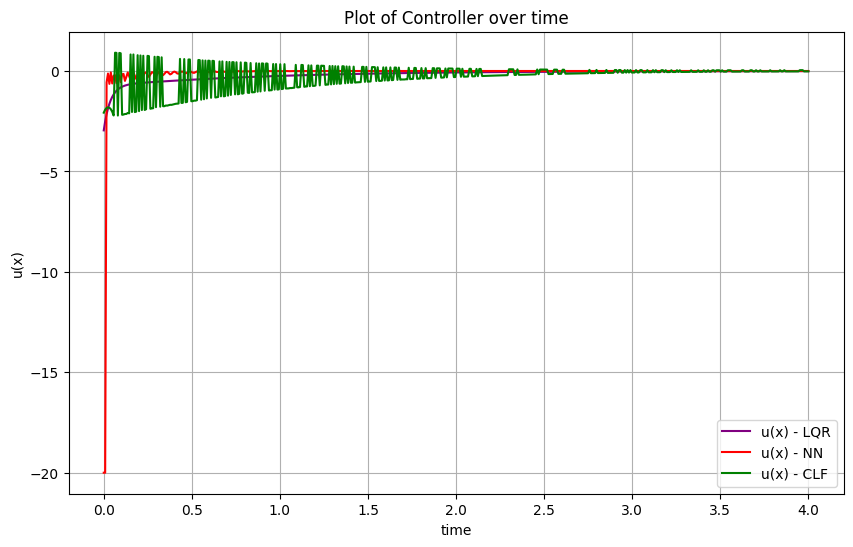

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(t_vals_C, u_val_LQR[:, 1], label="u(x) - LQR", color="purple")
plt.plot(t_vals_C, u_val_NN[:, 1], label="u(x) - NN", color="red")
plt.plot(t_vals_C, u_val_CLF[:, 1], label="u(x) - CLF", color="green")
plt.xlabel("time")
plt.ylabel("u(x)")
plt.title("Plot of Controller over time")
plt.legend()
plt.grid()
plt.show()

In [19]:
x1_vals_C[-1]

-0.01827169463549117

In [20]:
import pygame
import numpy as np
import imageio  # NEW: For saving GIFs

# Pygame Setup
WIDTH, HEIGHT = 600, 600
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
RED = (200, 0, 0)
FPS = 60  # Frame rate

# Length of pendulum in pixels (scaling factor)
l_pixels = 150  # Adjust for better visualization

# Initialize pygame
pygame.init()
screen = pygame.display.set_mode((WIDTH, HEIGHT))
clock = pygame.time.Clock()

# Prepare to Save Frames
frames = []  # List to store frames

# Simulation Variables
frame_index = 0  # Track current frame

# Simulation Loop
running = True
while running:
    screen.fill(WHITE)  # Clear screen
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    # Update frame index
    if frame_index < len(t_vals_C) - 1:
        theta = x1_vals_C[frame_index]  # Get theta from precomputed solution
        frame_index += 1
    else:
        frame_index = 0
        #running = False  # Stop animation when done

    #  Ensure theta is measured **from the vertical (UP)**
    theta_corrected = theta + np.pi  # Shift reference frame so upright is 0

    # Convert to screen coordinates (Y is flipped in pygame)
    origin = (WIDTH // 2, HEIGHT // 2)  # Pivot point (fixed point of pendulum)
    pend_x = int(origin[0] + l_pixels * np.sin(theta_corrected))  # X coordinate
    pend_y = int(origin[1] + l_pixels * np.cos(theta_corrected))  # Y coordinate (flipped)

    # Draw Pendulum
    pygame.draw.line(screen, BLACK, origin, (pend_x, pend_y), 5)  # Rod
    pygame.draw.circle(screen, RED, (pend_x, pend_y), 15)  # Mass

    pygame.display.flip()  # Update screen
    clock.tick(FPS)  # Maintain frame rate

    # Save frame (convert Pygame surface to numpy array)
    frame = pygame.surfarray.array3d(screen)  # Convert to NumPy array
    #frame = np.rot90(frame)  # Rotate to match standard orientation
    #frame = np.fliplr(frame)  # Flip horizontally to fix mirroring
    frames.append(frame)  # Store frame for GIF

pygame.quit()

# Save frames as GIF
#imageio.mimsave("pendulum_animation.gif", frames, fps=FPS)
#print("GIF saved as 'pendulum_animation.gif'")


pygame 2.6.1 (SDL 2.28.4, Python 3.10.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


KeyboardInterrupt: 